In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import random
import scipy
import functools

In [2]:
class PDE:

    def __init__(self, u0, c0):
        self.S_left = 0.9
        self.u0 = u0
        self.c0 = c0
        
        self.S_wc = 0.2
        self.S_gr = 0.1
        

    def k_rw(self, S):
        return ((S[..., 0] - self.S_wc) / (1 - self.S_wc - self.S_gr)) ** 4
    
    def k_rg(self, S):
        return ((1 - S[..., 0] - self.S_gr) / (1 - self.S_wc - self.S_gr)) ** 2

    def mu_w(self, S):
        return 1e-3 * (1.0 + 0.5 * S[..., 1])

    def mu_g(self, S):
        return 1e-5
    
    def f(self, S):
        lambda_w = self.k_rw(S) / self.mu_w(S)
        lambda_g = self.k_rg(S) / self.mu_g(S)
        return lambda_w / (lambda_w + lambda_g)

    

In [3]:
 pde = PDE(lambda x: x[:, 1:] * 0.0 + 0.7, lambda x: x[:, 1:] * 1.0)

In [4]:
def sample_points(N_colocacao, N_contorno, N_inicial, max_t = 0.75):
    X_colocacao = torch.cat([
        (1 - torch.rand(N_colocacao, 1)) * max_t,
        torch.rand(N_colocacao, 1)
    ], dim = 1)

    X_contorno = torch.cat([
        (1 - torch.rand(N_contorno, 1)) * max_t, 
        torch.zeros(N_contorno, 1)
    ], dim = 1)

    X_inicial = torch.cat([
        torch.zeros(N_inicial, 1),
        torch.rand(N_inicial, 1)
    ], dim = 1)

    return X_colocacao, X_contorno, X_inicial

def replace_least_error_points(points, new_points, errors):

    N_todos = points.shape[0]
    N_novos = new_points.shape[0]
    N_resto = N_todos - N_novos
    
    idxs = np.argpartition(-errors.detach().numpy(), N_resto, axis=0).flatten()
    idxs = idxs[:N_resto]

    return torch.cat((points[idxs], new_points), axis=0)    

def resample_ozanski(X_colocacao, X_contorno, X_inicial, model, perc=0.15, perc_boundary=0.1, lambda_1=0.1, max_t = 0.75):

    X_todos = torch.cat((X_contorno, X_inicial, X_colocacao), dim=0).requires_grad_(True)
    
    N_colocacao = X_colocacao.shape[0]
    N_contorno = X_contorno.shape[0]
    N_inicial = X_inicial.shape[0]

    y_fake = model(X_todos)
    y_fake_contorno = y_fake[0:N_contorno, :]
    y_fake_inicial = y_fake[N_contorno:N_contorno + N_inicial, :]

    L_f, L_b1, L_b2 = pinn_loss(X_todos, y_fake, X_contorno, y_fake_contorno, X_inicial, y_fake_inicial, make_reduction=False)

    loss_contorno = L_f[0:N_contorno, :] + lambda_1 * L_b2
    loss_inicial = L_f[N_contorno:N_contorno + N_inicial, :] + lambda_1 * L_b1
    loss_colocacao = L_f[N_contorno + N_inicial:, :]

    X_novos_colocacao, X_novos_contorno, X_novos_inicial = sample_points(int(N_colocacao * perc), int(N_contorno * perc_boundary), int(N_inicial * perc_boundary), max_t)

    X_final_colocacao = replace_least_error_points(X_colocacao, X_novos_colocacao, loss_colocacao)
    X_final_contorno = replace_least_error_points(X_contorno, X_novos_contorno, loss_contorno)
    X_final_inicial = replace_least_error_points(X_inicial, X_novos_inicial, loss_inicial)

    return X_final_colocacao, X_final_contorno, X_final_inicial


In [5]:
def pinn_loss(X_batch, y_fake, X_contorno, y_contorno, X_inicial, y_inicial, lambda_1 = 1.0, make_reduction=True):

    S = y_fake[:, 0:1]
    C = y_fake[:, 1:2]
    # SC = S * C

    f_val = pde.f(y_fake)
    # fC = f_val * C
    
    
    dS_dX = torch.autograd.grad(S, X_batch, grad_outputs=torch.ones_like(S), create_graph=True)[0]
    dC_dX = torch.autograd.grad(C, X_batch, grad_outputs=torch.ones_like(C), create_graph=True)[0]
    # dSC_dX = torch.autograd.grad(SC, X_batch, grad_outputs=torch.ones_like(SC), create_graph=True)[0]
    
    df_dX = torch.autograd.grad(f_val, X_batch, grad_outputs=torch.ones_like(f_val), create_graph=True)[0]
    # dfC_dX = torch.autograd.grad(fC, X_batch, grad_outputs=torch.ones_like(fC), create_graph=True)[0]

    
    dS_dt = dS_dX[:, 0:1]
    dS_dx = dS_dX[:, 1:2]
    dC_dt = dC_dX[:, 0:1]
    dC_dx = dC_dX[:, 1:2]
    # dSC_dt = dSC_dX[:, 0:1]
    dSC_dt = S * dC_dt + dS_dt * C
    
    df_dx = df_dX[:, 1:2]
    # dfC_dx = dfC_dX[:, 1:2]
    dfC_dx = f_val * dC_dx + df_dx * C
    

    if make_reduction:
        L_f = torch.mean((dS_dt + df_dx) ** 2) + torch.mean((dSC_dt + dfC_dx) ** 2)
        L_b1 = torch.mean((y_inicial[:, 0:1] - pde.u0(X_inicial)) ** 2) + torch.mean((y_inicial[:, 1:2] - pde.c0(X_inicial)) ** 2)
        L_b2 = torch.mean((y_contorno[:, 0:1] - 0.9) ** 2) + torch.mean((y_contorno[:, 1:2] - 0.0) ** 2)
    
        return L_f, L_b1, L_b2
    else:
        L_f = (dS_dt + df_dx) ** 2 + (dSC_dt + dfC_dx) ** 2
        L_b1 = (y_inicial[:, 0:1] - pde.u0(X_inicial)) ** 2 + (y_inicial[:, 1:2] - pde.c0(X_inicial)) ** 2
        L_b2 = (y_contorno[:, 0:1] - 0.9) ** 2 + (y_contorno[:, 1:2] - 0.0) ** 2
        
        return L_f, L_b1, L_b2

In [6]:
def pde_loss(X_batch, y_fake, lambda_1 = 1.0):

    S = y_fake[:, 0:1]
    C = y_fake[:, 1:2]
    
    f_val = pde.f(y_fake)
    
    dS_dX = torch.autograd.grad(S, X_batch, grad_outputs=torch.ones_like(S), create_graph=True)[0]
    dC_dX = torch.autograd.grad(C, X_batch, grad_outputs=torch.ones_like(C), create_graph=True)[0]
    df_dX = torch.autograd.grad(f_val, X_batch, grad_outputs=torch.ones_like(f_val), create_graph=True)[0]
    
    dS_dt = dS_dX[:, 0:1]
    dS_dx = dS_dX[:, 1:2]
    dC_dt = dC_dX[:, 0:1]
    dC_dx = dC_dX[:, 1:2]
    dSC_dt = S * dC_dt + dS_dt * C
    
    df_dx = df_dX[:, 1:]
    dfC_dx = f_val * dC_dx + df_dx * C

    return torch.mean((dS_dt + df_dx) ** 2) + torch.mean((dSC_dt + dfC_dx) ** 2)

In [7]:
class PINN(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net_all = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 8),
            nn.Sigmoid(),
        )
        
        self.net_RH1 = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )
        
        self.net_RH2 = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, z):
        
        descontinuidade1 = self.net_RH1(z[:, 0:1]) # z[:, 1:2] > descontinuidade1 => já passou o choque da saturação (usa net_IC**)
        descontinuidade2 = self.net_RH2(z[:, 0:1]) # z[:, 1:2] > descontinuidade2 => já passou o choque do sal (usa net_**IC)

        saidas = self.net_all(z).view(-1, 4, 2)
        # saidas[:, 0, :] = BCBC
        # saidas[:, 1, :] = BCIC
        # saidas[:, 2, :] = ICBC
        # saidas[:, 3, :] = ICIC
        
        cond1 = z[:, 1:2] > descontinuidade1
        cond2 = z[:, 1:2] > descontinuidade2
        idx = (cond1.long() * 2 + cond2.long()).flatten()

        return saidas[torch.arange(idx.shape[0]), idx, :]

In [8]:
N_colocacao = 15000
N_contorno = 1500
N_inicial = 1500

X_colocacao, X_contorno, X_inicial = sample_points(N_colocacao, N_contorno, N_inicial)

batch_size = 512
batch_contorno = batch_size // 7
batch_inicial = batch_size // 7
batch_colocacao = batch_size - batch_contorno - batch_inicial

PINN_model = PINN(32)

n_iter = 50000
lr = 1e-3
optimizer_all = optim.Adam(PINN_model.net_all.parameters(), lr=lr)
optimizer_RH1 = optim.Adam(PINN_model.net_RH1.parameters(), lr=1e-4)
optimizer_RH2 = optim.Adam(PINN_model.net_RH2.parameters(), lr=1e-4)

In [9]:
ts_treino = torch.linspace(0.0, 0.75, 100, dtype=torch.float32).reshape(-1, 1).requires_grad_(True)

In [10]:
def train_net_all():
    X_batch_colocacao = X_colocacao[torch.randint(0, N_colocacao, (batch_colocacao,))]
    X_batch_contorno = X_contorno[torch.randint(0, N_contorno, (batch_contorno,))]
    X_batch_inicial = X_inicial[torch.randint(0, N_inicial, (batch_inicial,))]

    X_batch = torch.cat((X_batch_inicial, X_batch_contorno, X_batch_colocacao), dim=0).requires_grad_(True)
    idx_inicial = slice(0, batch_inicial)
    idx_contorno = slice(batch_inicial, batch_inicial + batch_contorno)
    
    y_fake_all = PINN_model.net_all(X_batch).view(-1, 4, 2)
    y_fake_ICIC = y_fake_all[:, 3, :]
    y_fake_ICBC = y_fake_all[:, 2, :]
    y_fake_BCIC = y_fake_all[:, 1, :]
    y_fake_BCBC = y_fake_all[:, 0, :]

    L_pde_ICIC = pde_loss(X_batch, y_fake_ICIC)
    L_pde_ICBC = pde_loss(X_batch, y_fake_ICBC)
    L_pde_BCIC = pde_loss(X_batch, y_fake_BCIC)
    L_pde_BCBC = pde_loss(X_batch, y_fake_BCBC)

    L_ICIC = L_pde_ICIC + \
        torch.mean((y_fake_ICIC[idx_inicial, 0:1] - pde.u0(X_batch_inicial)) ** 2) + \
        torch.mean((y_fake_ICIC[idx_inicial, 1:2] - pde.c0(X_batch_inicial)) ** 2)
    L_ICBC = L_pde_ICBC + \
        torch.mean((y_fake_ICBC[idx_inicial, 0:1] - pde.u0(X_batch_inicial)) ** 2) + \
        torch.mean((y_fake_ICBC[idx_contorno, 1:2] - 0.0) ** 2)
    L_BCIC = L_pde_BCIC + \
        torch.mean((y_fake_BCIC[idx_contorno, 0:1] - 0.9) ** 2) + \
        torch.mean((y_fake_BCIC[idx_inicial, 1:2] - pde.c0(X_batch_inicial)) ** 2)
    L_BCBC = L_pde_BCBC + \
        torch.mean((y_fake_BCBC[idx_contorno, 0:1] - 0.9) ** 2) + \
        torch.mean((y_fake_BCBC[idx_contorno, 1:2] - 0.0) ** 2)

    L_all = L_ICIC + L_ICBC + L_BCIC + L_BCBC
    
    optimizer_all.zero_grad()
    L_all.backward()
    optimizer_all.step()

    return L_all

def train_net_RH():
    descontinuidade1 = PINN_model.net_RH1(ts_treino)
    descontinuidade2 = PINN_model.net_RH2(ts_treino)
    pontos_descontinuidade1 = torch.column_stack((ts_treino, descontinuidade1))
    pontos_descontinuidade2 = torch.column_stack((ts_treino, descontinuidade2))

    speed1 = torch.autograd.grad(descontinuidade1, ts_treino, grad_outputs=torch.ones_like(descontinuidade1), create_graph=True)[0]
    speed2 = torch.autograd.grad(descontinuidade2, ts_treino, grad_outputs=torch.ones_like(descontinuidade2), create_graph=True)[0]
    
    with torch.no_grad():
        cond = descontinuidade1 > descontinuidade2
        u1 = PINN_model.net_all(pontos_descontinuidade1).view(-1, 4, 2)
        u1_ICIC = u1[:, 3, :]
        u1_ICBC = u1[:, 2, :]
        u1_BCIC = u1[:, 1, :]
        u1_BCBC = u1[:, 0, :]
        
        u_l1 = torch.where(cond, u1_ICIC, u1_ICBC)
        u_r1 = torch.where(cond, u1_BCIC, u1_BCBC)


        u2 = PINN_model.net_all(pontos_descontinuidade2).view(-1, 4, 2)
        u2_ICIC = u2[:, 3, :]
        u2_ICBC = u2[:, 2, :]
        u2_BCIC = u2[:, 1, :]
        u2_BCBC = u2[:, 0, :]
        
        u_l2 = torch.where(~cond, u2_BCIC, u2_ICIC)
        u_r2 = torch.where(~cond, u2_BCBC, u2_ICBC)
        
        f_l1 = pde.f(u_l1)
        f_r1 = pde.f(u_r1)
        
        f_l2 = pde.f(u_l2)
        f_r2 = pde.f(u_r2)

    L_RH1 = torch.mean((speed1 * (u_l1[:, 0:1] - u_r1[:, 0:1]) - (f_l1 - f_r1)) ** 2) + descontinuidade1[0] ** 2
    L_RH2 = torch.mean((speed2 * (u_l2[:, 0:1] * u_l2[:, 1:2] - u_r2[:, 0:1] * u_r2[:, 1:2]) - (f_l2 * u_l2[:, 1:2] - f_r2 * u_r2[:, 1:2])) ** 2) + descontinuidade2[0] ** 2

    optimizer_RH1.zero_grad()
    L_RH1.backward()
    optimizer_RH1.step()
    
    optimizer_RH2.zero_grad()
    L_RH2.backward()
    optimizer_RH2.step()

    return L_RH1, L_RH2

In [11]:
L_RH1 = L_RH2 = torch.tensor([0])

In [12]:
for it in range(50):
    for i in range(200):
        L_all = train_net_all()

    for i in range(1000):
        L_RH1, L_RH2 = train_net_RH()
    
    print(f"Iter {it+1}: L_all={L_all.item():.10f}, L_RH1={L_RH1.item():.10f}, L_RH2={L_RH2.item():.10f}")

Iter 1: L_all=0.0466391146, L_RH1=0.0001091156, L_RH2=0.0000012110
Iter 2: L_all=0.0152983898, L_RH1=0.0019036345, L_RH2=0.0000017204
Iter 3: L_all=0.0099179745, L_RH1=0.0035913999, L_RH2=0.0000128971
Iter 4: L_all=0.0065869465, L_RH1=0.0063807326, L_RH2=0.0000410828
Iter 5: L_all=0.0031548953, L_RH1=0.0076227696, L_RH2=0.0000818664
Iter 6: L_all=0.0026758255, L_RH1=0.0113323098, L_RH2=0.0000668638
Iter 7: L_all=0.0025637925, L_RH1=0.0125117982, L_RH2=0.0000000988
Iter 8: L_all=0.0021448657, L_RH1=0.0132420445, L_RH2=0.0000002681
Iter 9: L_all=0.0017474666, L_RH1=0.0134796659, L_RH2=0.0000502215
Iter 10: L_all=0.0022128236, L_RH1=0.0126680052, L_RH2=0.0000001506
Iter 11: L_all=0.0022482469, L_RH1=0.0116573162, L_RH2=0.0000438218
Iter 12: L_all=0.0018862875, L_RH1=0.0101383366, L_RH2=0.0000383854
Iter 13: L_all=0.0010127205, L_RH1=0.0089808134, L_RH2=0.0000356104
Iter 14: L_all=0.0016015802, L_RH1=0.0084751025, L_RH2=0.0000000952
Iter 15: L_all=0.0009206675, L_RH1=0.0080391830, L_RH2=0.

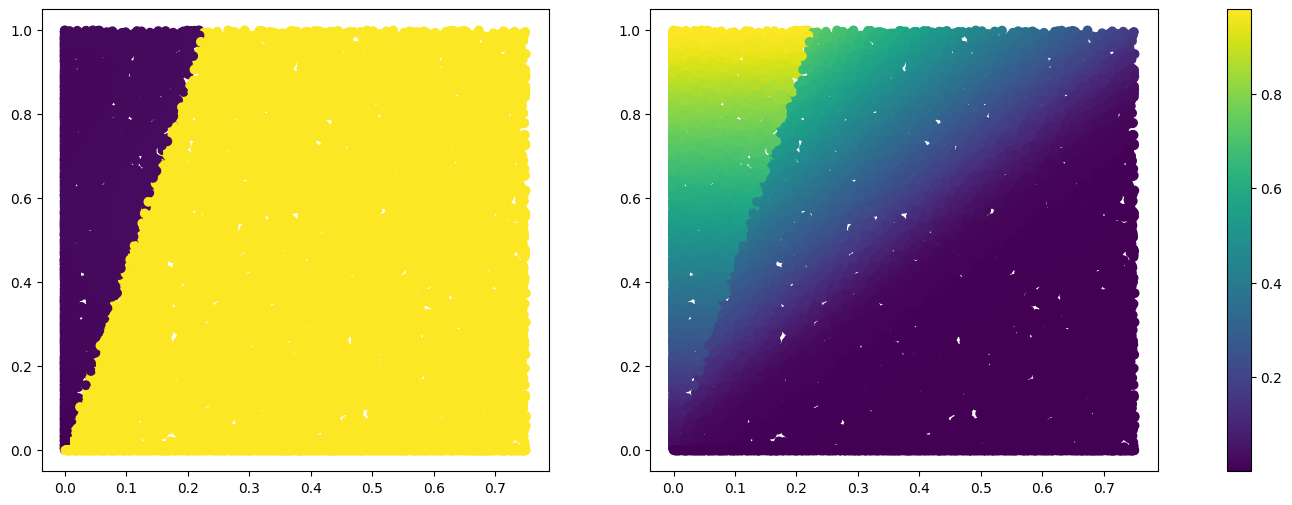

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

x_plot = torch.cat((X_colocacao, X_inicial, X_contorno))
y_pred = PINN_model(x_plot).detach().numpy()
x_plot = x_plot.detach().numpy()

sc = axes[0].scatter(x_plot[:, 0], x_plot[:, 1:], c=y_pred[:, 0:1], cmap="viridis")
sc = axes[1].scatter(x_plot[:, 0], x_plot[:, 1:], c=y_pred[:, 1:2], cmap="viridis")
fig.colorbar(sc, ax=axes, orientation='vertical')

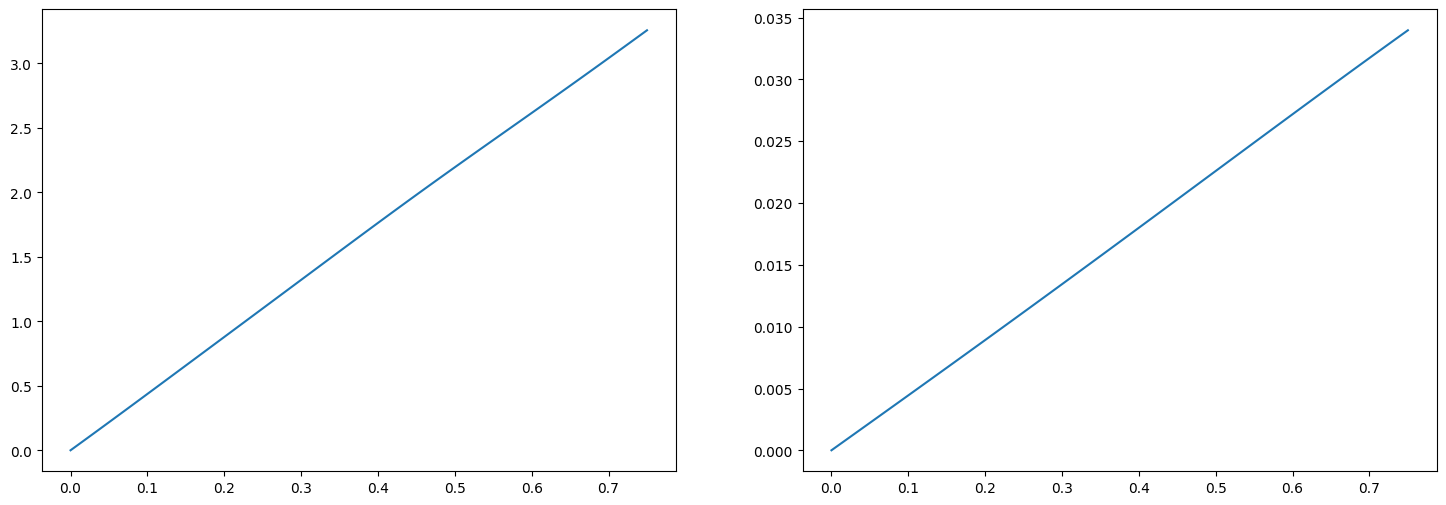

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].plot(ts_treino.detach(), PINN_model.net_RH1(ts_treino).detach())
axes[1].plot(ts_treino.detach(), PINN_model.net_RH2(ts_treino).detach())

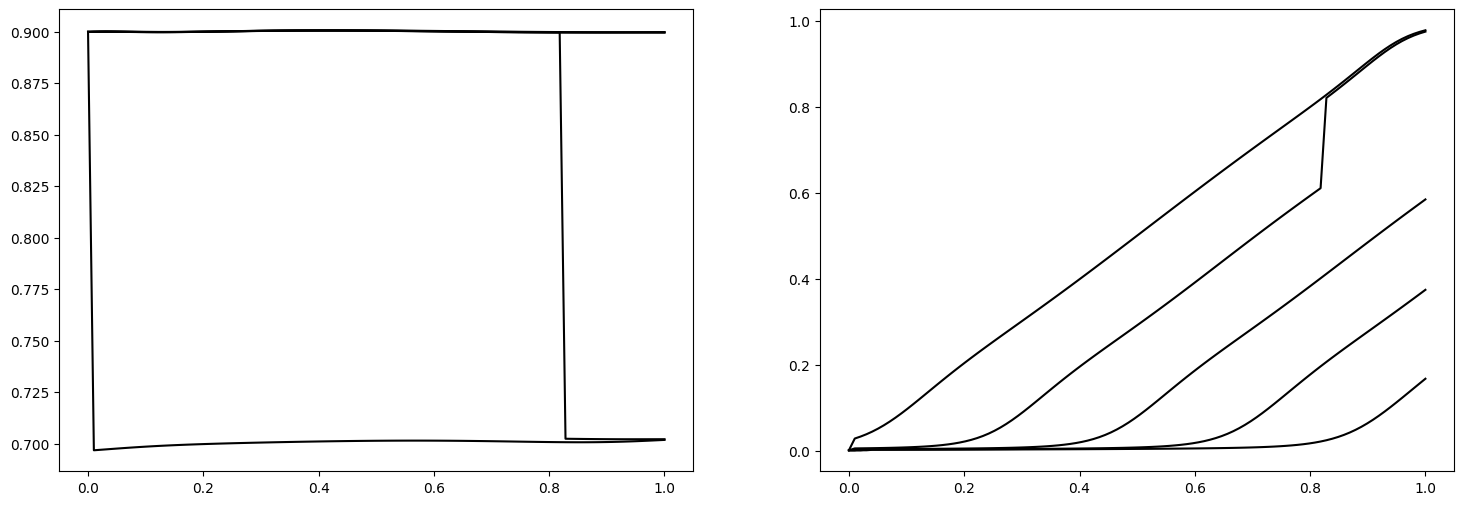

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for idx, t in enumerate(np.linspace(0, 0.75, 5)):
    xs = np.linspace(0, 1, 100)
    X = torch.tensor(np.stack([np.full(100, t), xs], axis=1), dtype=torch.float32)
    SC = PINN_model(X).detach()

    axes[0].plot(xs, SC[:, 0:1], label=f't = {t/3600:.1f} h', color="black")
    axes[1].plot(xs, SC[:, 1:2], label=f't = {t/3600:.1f} h', color="black")